# Day 3 · 神经网络核心：nn.Module / Loss / backward / Optimizer

**今天的目标**：搞懂深度学习最核心的一件事 —— **机器怎么「学会」参数**。

Day 2 你学的是 tensor（数据容器）。今天开始，数据流动起来了：

```
输入 x
  |  forward（前向）
预测 y_pred
  |  和答案 y_true 比
loss（差多少）
  |  backward（反向）
每个参数的梯度
  |  optimizer（更新）
参数变好一点点  ->  回到第一步，再来一遍
```

**这四步循环，就是所有深度学习（包括 VLA）的内核。** 今天不碰复杂模型，就用最简单的线性模型把它完整走通。

> 第 0 节是 Day 2 的遗留：broadcasting / sum·mean / view vs reshape —— 它们是算 loss 的必备前置。

In [ ]:
import torch
import torch.nn as nn

print('torch:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

## 0.1 热身：broadcasting（广播）

两个**形状不一样**的 tensor 也能做运算 —— 前提是其中一个能「撑开」去匹配另一个。规则：

- 从**最后一维**开始往前比
- 两维相等 -> 通过
- 其中一个是 1 -> 撑开成另一个的大小
- 都不是 1 又不相等 -> 报错

为什么重要：算 loss 时的 `y_pred - y_true`、加 bias、归一化，全靠它。

In [3]:
import torch
import torch.nn as nn
a = torch.ones(3, 4)
b = torch.ones(1, 4)
print(a)
print(b)
print('a', a.shape, '+ b', b.shape, '->', (a + b).shape)
print(a + b)
c = torch.arange(3).reshape(3, 1)   # (3, 1)
d = torch.arange(4).reshape(1, 4)   # (1, 4)
print(c)
print(d)
print('c', c.shape, '+ d', d.shape, '->', (c + d).shape)
print(c + d)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[1., 1., 1., 1.]])
a torch.Size([3, 4]) + b torch.Size([1, 4]) -> torch.Size([3, 4])
tensor([[2., 2., 2., 2.],
        [2., 2., 2., 2.],
        [2., 2., 2., 2.]])
tensor([[0],
        [1],
        [2]])
tensor([[0, 1, 2, 3]])
c torch.Size([3, 1]) + d torch.Size([1, 4]) -> torch.Size([3, 4])
tensor([[0, 1, 2, 3],
        [1, 2, 3, 4],
        [2, 3, 4, 5]])


In [ ]:
# 练习 1（有提示）
# a 是 (2, 3)，b 是 (2, 1)。它们相加结果是什么形状？先猜，再跑。
# 然后自己造一个【会报错】的例子，跑出来读读报错。
import torch
import torch.nn as nn
a = torch.ones(2, 3)
b = torch.ones(2, 1)
print(a)
print(b)
print(a+b)
print((a + b).shape)



tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[1., 1.],
        [1., 1.]])


RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

## 0.2 热身：sum / mean / dim

`sum()` 和 `mean()` 把一堆数压成一个数。关键是 `dim` 参数 —— 它决定**沿着哪个方向压**：

- `x.sum()` —— 所有元素加起来，得到一个标量
- `x.sum(dim=0)` —— 沿第 0 维压，结果里就少掉第 0 维
- `x.mean(dim=1)` —— 同理

记住一句话：**用了 `dim=n`，结果的形状就是原形状去掉第 n 维。**

In [9]:
x = torch.arange(12).reshape(3, 4).float()
print('x =')
print(x)
print('全部求和      :', x.sum())
print('sum(dim=0) ->', x.sum(dim=0).shape, x.sum(dim=0))   # 竖着压，4 个数
print('sum(dim=1) ->', x.sum(dim=1).shape, x.sum(dim=1))   # 横着压，3 个数
print('mean(dim=0) ->', x.mean(dim=0))
# 练习 2（有提示）
# 用上面的 x，做两件事：
#   (a) 求每一行的平均值，形状应该是 (3,)
#   (b) 求每一列的最大值
#       （注意：x.max(dim=0) 返回的是一个 tuple，不是单个 tensor）
print(x.sum(dim=1)/4)
col_max, col_argmax = x.max(dim=0)
print(col_max)                  # tensor([ 8.,  9., 10., 11.])
print(col_argmax)

x =
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
全部求和      : tensor(66.)
sum(dim=0) -> torch.Size([4]) tensor([12., 15., 18., 21.])
sum(dim=1) -> torch.Size([3]) tensor([ 6., 22., 38.])
mean(dim=0) -> tensor([4., 5., 6., 7.])
tensor([1.5000, 5.5000, 9.5000])
tensor([ 8.,  9., 10., 11.])
tensor([2, 2, 2, 2])


## 0.3 热身：view vs reshape

两个都能改形状，区别在**内存**：

- `reshape` —— 内存不连续就**复制一份**，保证能改成功
- `view` —— 只在内存连续时才允许，**不复制**，直接换读法；不连续就报错

实用建议：**平时用 `reshape` 更省心**；追求性能、且确定内存连续时才用 `view`。

In [ ]:
x = torch.arange(12)
print('view(3, 4)    ->', x.view(3, 4).shape)
print('reshape(3, 4) ->', x.reshape(3, 4).shape)

# 转置之后内存就不连续了
y = x.reshape(3, 4).t()
print('y 连续吗 :', y.is_contiguous())
try:
    y.view(12)
except RuntimeError as e:
    print('view 报错 :', str(e)[:70], '...')
print('reshape 可以 :', y.reshape(12).shape)
# 练习 3（有提示）
# 用 contiguous() 让 y 变连续，然后再 view(12) 试试 —— 还报错吗？
y = x.reshape(3, 4).t()

# 先让 y 变连续
y_cont = y.contiguous()
print('y_cont 连续吗 :', y_cont.is_contiguous())   # True

# 现在可以 view 了
print('view 成功 :', y_cont.view(12).shape)        # torch.Size([12])                                                                                                       


view(3, 4)    -> torch.Size([3, 4])
reshape(3, 4) -> torch.Size([3, 4])
y 连续吗 : False
view 报错 : view size is not compatible with input tensor's size and stride (at le ...
reshape 可以 : torch.Size([12])
y_cont 连续吗 : True
view 成功 : torch.Size([12])


## 1. 训练到底在做什么

一句话：**调参数，让 loss 变小。**

我们拿一个最小例子把过程摊开 —— 让模型学出 `y = 3x + 2` 这个规律。模型就是 `w*x + b`，一开始 `w`、`b` 都是 0。

关键问题：怎么知道 `w` 该往大调还是往小调？

**靠梯度。** 而 `loss.backward()` 帮你自动算出来。

In [20]:
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = 3 * x + 2                      # 我们想让模型学出来的规律

# requires_grad=True：告诉 PyTorch「盯着它，要算它的梯度」
w = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([[0.0]], requires_grad=True)

y_pred = x @ w + b                          # forward
loss = ((y_pred - y_true) ** 2).mean()      # loss
print('初始 loss :', loss.item())

loss.backward()                             # backward：自动算梯度
print('w.grad    :', w.grad.item())
print('b.grad    :', b.grad.item())

# 梯度告诉我们：往【负梯度】方向挪一点，loss 就会变小
w.data -= 0.01 * w.grad
b.data -= 0.01 * b.grad
y_pred = x @ w + b
print('挪一步后 loss :', ((y_pred - y_true) ** 2).mean().item())
# 练习 4（有提示）
# 上面只手动挪了一步。把它改成循环，连续挪 200 步，
# 看看最后 w 和 b 是不是接近 3 和 2。
#
# 注意：每次挪之前要先 w.grad.zero_()、b.grad.zero_()，
#       否则梯度会累积（为什么？下一节会讲）
for step in range(1000):
    w.grad.zero_()
    b.grad.zero_()
    y_pred = x @ w + b
    loss = ((y_pred - y_true) ** 2).mean()
    loss.backward()
    w.data -= 0.01 * w.grad
    b.data -= 0.01 * b.grad   
    step+=1
print('最终 w :', w.item())
print('最终 b :', b.item())

初始 loss : 101.5
w.grad    : -55.0
b.grad    : -19.0
挪一步后 loss : 70.46734619140625
最终 w : 3.014847993850708
最终 b : 1.956344723701477


## 2. nn.Module —— 把模型装进一个类

手动管 `w` 和 `b` 太原始。PyTorch 的规矩是：**模型继承 `nn.Module`**，参数放在 `__init__`，数据怎么流写在 `forward`。

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()          # 这一行必须有
        self.fc = nn.Linear(1, 1)   # 一层：输入 1 维 -> 输出 1 维

    def forward(self, x):
        return self.fc(x)
```

**这就是你 Day 1 写的 `class Robot` 的升级版** —— 只是套了个 `nn.Module` 的壳，好让 PyTorch 能自动找到你的参数。

In [24]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        return self.fc(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LinearRegression().to(device)
print(model)

# 看看它自己管了哪些参数
for name, p in model.named_parameters():
    print(name, '->', p.shape)
# 练习 5（有提示）
# 把 LinearRegression 改成【两层】：输入 1 维 -> 隐藏层 8 维 -> 输出 1 维
# forward 里中间加一个激活函数 torch.relu
# 提示：nn.Linear(1, 8) 然后 nn.Linear(8, 1)
class TwoLayerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x)
# 看看它自己管了哪些参数
for name, p in model.named_parameters():
    print(name, '->', p.shape)

LinearRegression(
  (fc): Linear(in_features=1, out_features=1, bias=True)
)
fc.weight -> torch.Size([1, 1])
fc.bias -> torch.Size([1])
fc.weight -> torch.Size([1, 1])
fc.bias -> torch.Size([1])


## 3. Loss —— 衡量「错得有多离谱」

loss 是一个**标量**（一个数），越小说明预测越接近答案。最常用的两个：

- `nn.MSELoss()` —— 回归（预测连续数值），即均方误差
- `nn.CrossEntropyLoss()` —— 分类（预测属于哪一类），你 Day 5 做 MNIST 就用它

**关键认知**：`loss.backward()` 只能作用在**标量**上。算出来的 loss 如果不是标量，要先 `.mean()` 或 `.sum()` 压成一个数。

In [27]:
criterion = nn.MSELoss()

y_pred = torch.tensor([[2.0], [4.0], [6.0]])
y_true = torch.tensor([[3.0], [4.0], [5.0]])
print('MSELoss :', criterion(y_pred, y_true).item())

# 手算验证：(1^2 + 0^2 + 1^2) / 3 = 0.6667
print('手算    :', ((y_pred - y_true) ** 2).mean().item())

MSELoss : 0.6666666865348816
手算    : 0.6666666865348816


In [28]:
# 练习 6（无提示）
# 自己算一遍：y_pred = [[1.], [1.]]，y_true = [[3.], [5.]] 的 MSE 是多少？
# 先用脑袋（或纸上）算出数字，再用 MSELoss 验证对不对。
criterion = nn.MSELoss()
y_pred = torch.tensor([[1.], [1.]])
y_true = torch.tensor([[3.], [5.]])
print('MSELoss :', criterion(y_pred, y_true).item())

MSELoss : 10.0


## 4. backward() —— 自动求导

`loss.backward()` 做的事：**从 loss 出发，沿着计算图往回走，用链式法则算出每个参数的梯度**，结果存进 `p.grad`。

你不需要会手推，但必须记住两件事：

1. **梯度会累加！** 不清零的话，下一次 backward 会加上去。所以每轮开头必须 `optimizer.zero_grad()`。
2. **算完梯度后计算图会被释放**（默认行为），想再 backward 一次得重新 forward。

In [ ]:
a = torch.tensor([1.0, 2.0], requires_grad=True)

loss1 = (a ** 2).sum()
loss1.backward()
print('第一次 grad :', a.grad)      # d/da (a^2) = 2a = [2, 4]

loss2 = (a ** 2).sum()
loss2.backward()
print('第二次 grad :', a.grad)      # 注意！累积了，变成 [4, 8]

a.grad.zero_()
loss3 = (a ** 2).sum()
loss3.backward()
print('清零后 grad :', a.grad)      # 回到 [2, 4]

In [ ]:
# 练习 7（无提示）
# 为什么第二次 backward 之后 grad 变成了两倍？用自己的话解释。
# 再想一步：如果训练循环里忘了 zero_grad()，loss 曲线会表现成什么样？
# （先在脑子里推，第 7 节挑战 2 会让你真的跑出来验证）



## 5. Optimizer —— 按梯度更新参数

`backward()` 只算出梯度，**真正改参数的是 optimizer**。

- `torch.optim.SGD(params, lr)` —— 最基础：`参数 -= lr * 梯度`
- `torch.optim.Adam(params, lr)` —— 更聪明，会自动调整每个参数的学习率；**入门期默认用它**

`lr`（学习率）是最重要的超参数：**太大会震荡不收敛，太小会慢到看不出变化**。

In [29]:
model = LinearRegression().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]], device=device)
y_true = 3 * x + 2

for step in range(300):
    optimizer.zero_grad()               # 1. 清空旧梯度
    y_pred = model(x)                   # 2. 前向
    loss = criterion(y_pred, y_true)    # 3. 算 loss
    loss.backward()                     # 4. 反向算梯度
    optimizer.step()                    # 5. 更新参数
    print(f'step {step}: loss = {loss.item():.4f}')
print('最终 w :', model.fc.weight.item())
print('最终 b :', model.fc.bias.item())
# 练习 8（有提示）
# 把上面的循环改成 200 步，并在结束后打印学到的 w 和 b —— 应该接近 3 和 2。
# 提示：model.fc.weight / model.fc.bias



step 0: loss = 80.1520
step 1: loss = 79.4955
step 2: loss = 78.8419
step 3: loss = 78.1911
step 4: loss = 77.5431
step 5: loss = 76.8980
step 6: loss = 76.2559
step 7: loss = 75.6168
step 8: loss = 74.9807
step 9: loss = 74.3477
step 10: loss = 73.7179
step 11: loss = 73.0912
step 12: loss = 72.4676
step 13: loss = 71.8473
step 14: loss = 71.2303
step 15: loss = 70.6165
step 16: loss = 70.0061
step 17: loss = 69.3990
step 18: loss = 68.7953
step 19: loss = 68.1950
step 20: loss = 67.5981
step 21: loss = 67.0047
step 22: loss = 66.4148
step 23: loss = 65.8283
step 24: loss = 65.2453
step 25: loss = 64.6659
step 26: loss = 64.0900
step 27: loss = 63.5176
step 28: loss = 62.9487
step 29: loss = 62.3835
step 30: loss = 61.8218
step 31: loss = 61.2637
step 32: loss = 60.7091
step 33: loss = 60.1582
step 34: loss = 59.6108
step 35: loss = 59.0671
step 36: loss = 58.5269
step 37: loss = 57.9903
step 38: loss = 57.4573
step 39: loss = 56.9279
step 40: loss = 56.4021
step 41: loss = 55.8799
st

## 6. 完整训练循环 —— 这五行你会写一辈子

```python
optimizer.zero_grad()          # 清梯度
y_pred = model(x)              # 前向
loss = criterion(y_pred, y)    # 算 loss
loss.backward()                # 反向
optimizer.step()               # 更新
```

**背下来。** 你以后写 MNIST、写 ViT、写 VLA 微调，内核都是这五行 —— 变的只是 `model` 和 `criterion` 换成了更复杂的。

外面再套两层：`for epoch`（整份数据跑几遍）× `for batch`（一轮里分几批跑）。这是 Day 4 的内容。

In [32]:
# 完整版：加 epoch，记录 loss 变化
model = LinearRegression().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.MSELoss()

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]], device=device)
y_true = 3 * x + 2

history = []
for epoch in range(200):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()
    history.append(loss.item())

print('前 3 个 loss :', [round(v, 4) for v in history[:3]])
print('后 3 个 loss :', [round(v, 4) for v in history[-3:]])
print('学到的 w     :', model.fc.weight.item())
print('学到的 b     :', model.fc.bias.item())

前 3 个 loss : [117.8802, 117.8794, 117.8786]
后 3 个 loss : [117.7231, 117.7223, 117.7215]
学到的 w     : -0.0630033016204834
学到的 b     : -0.6377913951873779


In [ ]:
# 练习 9（无提示）
# (a) lr 改成 1.0，跑一遍 —— loss 会怎样？为什么？
# (b) lr 改成 1e-5，跑一遍 —— 又会怎样？
# 把三种 lr 下最终的 w / b 记下来，然后想：学习率到底在控制什么？



## 7. 挑战（无提示，自己想办法）

机制你已经会了。下面两道是**真正的练习**，卡住了再回头翻前面的例子。

final loss = 0.004276479594409466


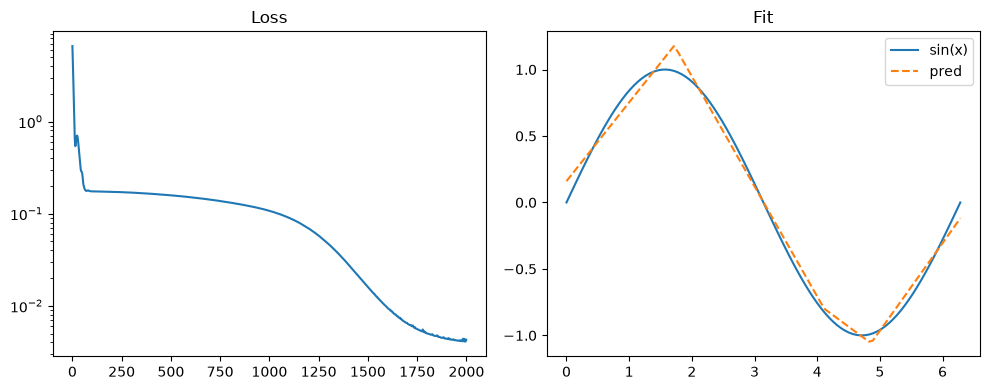

In [35]:
# 挑战 1
# 用两层网络（练习 5 写的那个）去拟合 y = sin(x)，
# x 取 0 到 2*pi 之间的 100 个点。
#
# 要求：跑完之后 loss 能降到 0.01 以下。调不动就去调 lr 和训练轮数。
# 提示：math.pi、torch.linspace、torch.sin

import torch, torch.nn as nn
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- 用你改好的两层网络 ----
class TwoLayerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc  = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc(x)))

model = TwoLayerNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)  # lr 调小一点更稳
criterion = nn.MSELoss()

x = torch.linspace(0, 2 * 3.1415926, 100).reshape(-1, 1).to(device)
y_true = torch.sin(x)

history = []
for epoch in range(2000):          # 200 对两层网络偏少，可加到 2000
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()
    history.append(loss.item())

# ---- 看结果 ----
print('final loss =', history[-1])

model.eval()
with torch.no_grad():
    y_pred = model(x)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history); plt.yscale('log'); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(x.cpu(), y_true.cpu(), label='sin(x)')
plt.plot(x.cpu(), y_pred.cpu(), '--', label='pred')
plt.legend(); plt.title('Fit')
plt.tight_layout(); plt.show()


final loss = 3.857125759124756


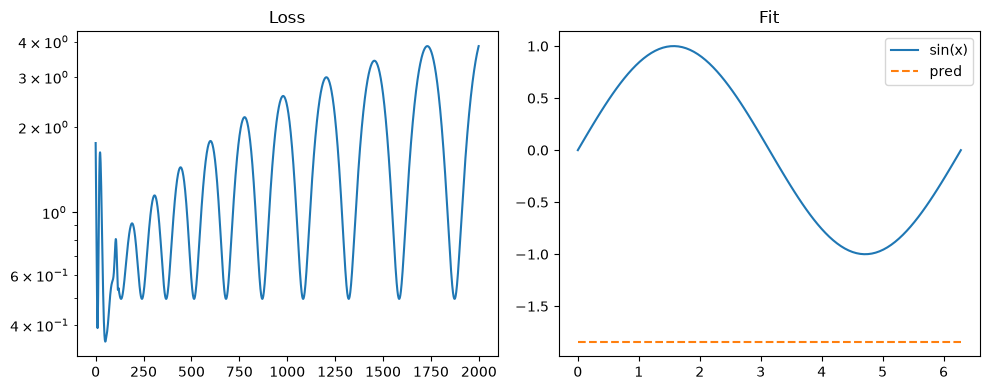

In [36]:
# 挑战 2
# 故意把 optimizer.zero_grad() 删掉，用线性回归跑 200 步，
# 观察 loss 怎么变。然后回答：为什么梯度不清零会出问题？
# 把现象和解释写进 README。

import torch, torch.nn as nn
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- 用你改好的两层网络 ----
class TwoLayerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc  = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc(x)))

model = TwoLayerNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)  # lr 调小一点更稳
criterion = nn.MSELoss()

x = torch.linspace(0, 2 * 3.1415926, 100).reshape(-1, 1).to(device)
y_true = torch.sin(x)

history = []
for epoch in range(2000):          # 200 对两层网络偏少，可加到 2000
    y_pred = model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()
    history.append(loss.item())

# ---- 看结果 ----
print('final loss =', history[-1])

model.eval()
with torch.no_grad():
    y_pred = model(x)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history); plt.yscale('log'); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(x.cpu(), y_true.cpu(), label='sin(x)')
plt.plot(x.cpu(), y_pred.cpu(), '--', label='pred')
plt.legend(); plt.title('Fit')
plt.tight_layout(); plt.show()

## 今天结束前，你应该能不查资料回答

1. 训练一个模型，反复循环的**四步**是哪四步？
2. `nn.Module` 里的 `__init__` 和 `forward` 各干什么？
3. `loss.backward()` 到底做了什么？
4. 为什么每轮开头要 `optimizer.zero_grad()`？
5. `nn.MSELoss` 和 `nn.CrossEntropyLoss` 分别用在哪？
6. 学习率 `lr` 太大 / 太小分别会怎样？
7. 上一节那个「五行」你闭着眼能默写出来吗？

答案写进 `week01/day03/README.md`，别留在这个笔记本里。